In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.gridspec import GridSpec
from scipy.stats import chi2 as chi2_dist
from scipy.stats import spearmanr
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

Helper functions for plotting

In [2]:
def truncate_cmap(
    cmap_name: str, min_val: float = 0.15, max_val: float = 1.0, n: int = 256
):
    """Return a version of *cmap_name* clipped to [min_val, max_val].

    This removes the near-white end so the gradient starts at a clearly
    visible light colour instead of white.
    """
    base = plt.get_cmap(cmap_name)
    colors = base(np.linspace(min_val, max_val, n))
    return LinearSegmentedColormap.from_list(f"{cmap_name}_trunc", colors, N=n)

Setting input and output paths

In [3]:
# setting result dir
results_dir = pathlib.Path("./results/moa_analysis").resolve(strict=True)

# setting output
output_dir = (pathlib.Path.cwd() / "plots").resolve()
output_dir.mkdir(exist_ok=True)

Loading in results

In [4]:
# loadding in moa results
moa_results_df = pl.read_parquet(results_dir / "mitocheck_moa_analysis_results.parquet")

# rerank treatment to remove duplicate ranks (nulls ranked last)
moa_results_df = moa_results_df.sort(
    ["ref_profile", "on_score", "off_score", "treatment"],
    nulls_last=True,
).with_columns((pl.int_range(pl.len()).over("ref_profile") + 1).alias("rank"))

moa_results_df.head()

rank,ref_profile,treatment,on_score,off_score,proportion
i64,str,str,f64,f64,f64
1,"""ADCCM""","""RGR""",2.0170e-14,0.0,0.430556
2,"""ADCCM""","""OGG1""",7.5791e-14,0.0,0.042553
3,"""ADCCM""","""COPB""",56.433104,0.0,0.0
4,"""ADCCM""","""CDK4""",214.88898,0.0,0.0
5,"""ADCCM""","""ENSG00000175216""",216.415006,0.0,0.0


convert data into pandas for plotting 

In [5]:
df = moa_results_df.to_pandas()

# Drop rows with no score data
df = df.dropna(subset=["on_score", "off_score"])

# # Re-rank within each ref_profile: lowest on_score first, then off_score as tiebreaker
# df = df.sort_values(["ref_profile", "on_score", "off_score", "treatment"]).reset_index(drop=True)
# df["rank"] = df.groupby("ref_profile").cumcount() + 1

profiles = sorted(df["ref_profile"].unique())
n_profiles = len(profiles)

Setting plot layout and color pallete 

Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/gene_rankings_phenotypic_state.png


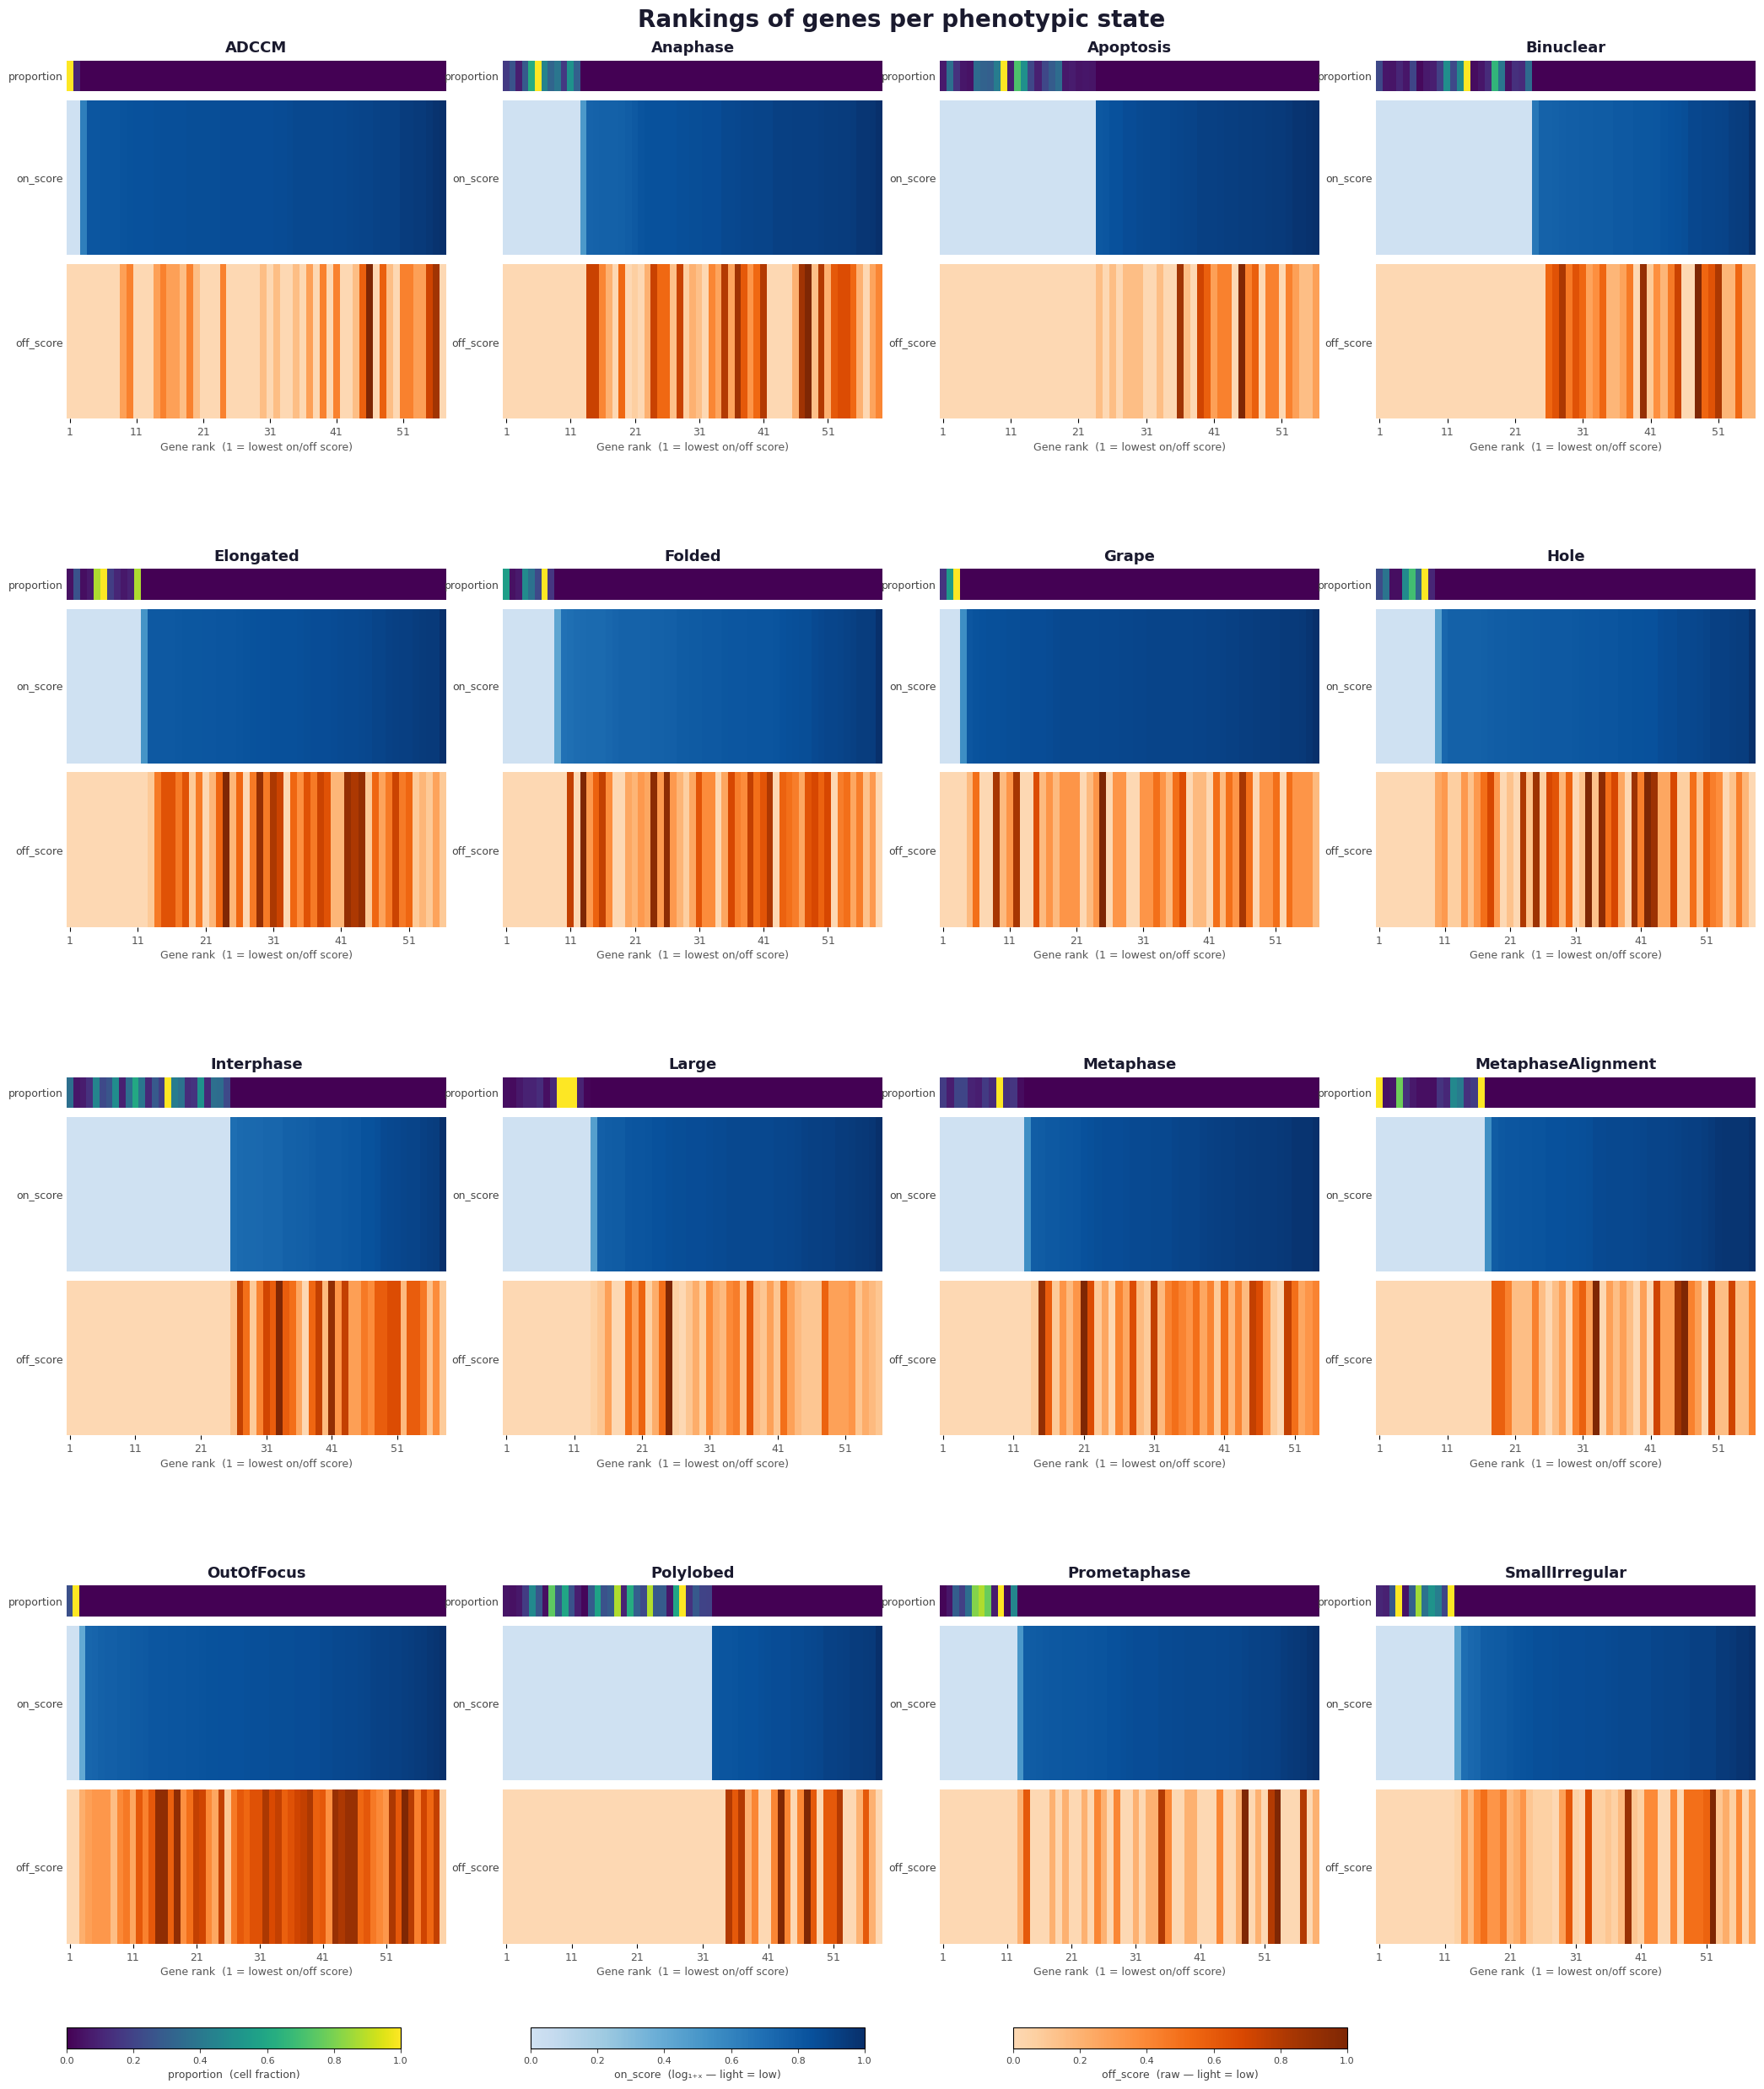

In [6]:
# setting plot parameters and color pallete
NCOLS = 4
NROWS = int(np.ceil(n_profiles / NCOLS))

fig = plt.figure(figsize=(22, NROWS * 6.2), facecolor="white")

fig.suptitle(
    "Rankings of genes per phenotypic state",
    fontsize=20,
    fontweight="bold",
    color="#1a1a2e",
    y=0.995,
)

CMAP_PROP = "viridis"
CMAP_ON = truncate_cmap("Blues", min_val=0.20)
CMAP_OFF = truncate_cmap("Oranges", min_val=0.20)

# build grid: each profile gets 3 stacked rows (proportion / on_score / off_score) ──
outer = GridSpec(
    NROWS,
    NCOLS,
    figure=fig,
    hspace=0.42,
    wspace=0.15,
    left=0.05,
    right=0.96,
    top=0.97,
    bottom=0.07,
)
for idx, profile in enumerate(profiles):
    row, col = divmod(idx, NCOLS)
    inner = outer[row, col].subgridspec(3, 1, hspace=0.08, height_ratios=[0.2, 1, 1])

    ax_prop = fig.add_subplot(inner[0])
    ax_on = fig.add_subplot(inner[1])
    ax_off = fig.add_subplot(inner[2])

    sub = df[df["ref_profile"] == profile].copy().head(60)
    n_genes = len(sub)

    on_scores = sub["on_score"].values
    off_scores = sub["off_score"].values
    proportions = (
        sub["proportion"].values if "proportion" in sub.columns else np.ones(n_genes)
    )

    on_log = np.log1p(on_scores).reshape(1, -1)
    off_raw = off_scores.reshape(1, -1)
    prop_raw = proportions.reshape(1, -1)

    # proportion heatmap
    ax_prop.imshow(
        prop_raw,
        aspect="auto",
        cmap=CMAP_PROP,
        vmin=0,
        vmax=max(float(proportions.max()), 0.01),
        interpolation="nearest",
    )
    ax_prop.set_yticks([0])
    ax_prop.set_yticklabels(["proportion"], fontsize=9, color="#444444")
    ax_prop.set_xticks([])
    ax_prop.tick_params(axis="y", length=0, pad=3)
    for spine in ax_prop.spines.values():
        spine.set_visible(False)
    ax_prop.set_facecolor("white")

    # on score heatmap
    ax_on.imshow(
        on_log,
        aspect="auto",
        cmap=CMAP_ON,
        vmin=0,
        vmax=max(float(np.log1p(on_scores).max()), 1),
        interpolation="nearest",
    )
    ax_on.set_yticks([0])
    ax_on.set_yticklabels(["on_score"], fontsize=9, color="#444444")
    ax_on.set_xticks([])
    ax_on.tick_params(axis="y", length=0, pad=3)
    for spine in ax_on.spines.values():
        spine.set_visible(False)
    ax_on.set_facecolor("white")

    # off score heatmap
    ax_off.imshow(
        off_raw,
        aspect="auto",
        cmap=CMAP_OFF,
        vmin=0,
        vmax=max(float(off_scores.max()), 0.01),
        interpolation="nearest",
    )
    ax_off.set_yticks([0])
    ax_off.set_yticklabels(["off_score"], fontsize=9, color="#444444")
    ax_off.tick_params(axis="y", length=0, pad=3)
    for spine in ax_off.spines.values():
        spine.set_visible(False)
    ax_off.set_facecolor("white")

    # X-axis tick marks every 10 genes, labelled as rank positions
    x_ticks = list(range(0, n_genes, 10))
    ax_off.set_xticks(x_ticks)
    ax_off.set_xticklabels([str(r + 1) for r in x_ticks], fontsize=9, color="#555555")
    ax_off.set_xlabel(
        "Gene rank  (1 = lowest on/off score)", fontsize=9, color="#555555", labelpad=3
    )

    # Profile title above proportion row
    ax_prop.set_title(
        profile, fontsize=13, fontweight="bold", color="#1a1a2e", pad=7, loc="center"
    )

# setting global colobars below all subplots
cbar_ax_prop = fig.add_axes([0.05, 0.020, 0.18, 0.010])
cbar_ax_on = fig.add_axes([0.30, 0.020, 0.18, 0.010])
cbar_ax_off = fig.add_axes([0.56, 0.020, 0.18, 0.010])

sm_prop = plt.cm.ScalarMappable(cmap=CMAP_PROP, norm=Normalize(vmin=0, vmax=1))
sm_prop.set_array([])
cb_prop = fig.colorbar(sm_prop, cax=cbar_ax_prop, orientation="horizontal")
cb_prop.set_label("proportion  (cell fraction)", fontsize=9, color="#444444")
cb_prop.ax.xaxis.set_tick_params(color="#444444", labelsize=8)
plt.setp(cb_prop.ax.xaxis.get_ticklabels(), color="#444444")

sm_on = plt.cm.ScalarMappable(cmap=CMAP_ON, norm=Normalize(vmin=0, vmax=1))
sm_on.set_array([])
cb_on = fig.colorbar(sm_on, cax=cbar_ax_on, orientation="horizontal")
cb_on.set_label("on_score  (log₁₊ₓ — light = low)", fontsize=9, color="#444444")
cb_on.ax.xaxis.set_tick_params(color="#444444", labelsize=8)
plt.setp(cb_on.ax.xaxis.get_ticklabels(), color="#444444")

sm_off = plt.cm.ScalarMappable(cmap=CMAP_OFF, norm=Normalize(vmin=0, vmax=1))
sm_off.set_array([])
cb_off = fig.colorbar(sm_off, cax=cbar_ax_off, orientation="horizontal")
cb_off.set_label("off_score  (raw — light = low)", fontsize=9, color="#444444")
cb_off.ax.xaxis.set_tick_params(color="#444444", labelsize=8)
plt.setp(cb_off.ax.xaxis.get_ticklabels(), color="#444444")

# save
out_path = output_dir / "gene_rankings_phenotypic_state.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()
plt.close()

## Analysis 2: Phenotype-level Consistency (Kendall's W + Cross-profile Rank Correlation)

The goal is to determine whether gene rankings are driven by the specific phenotypic profile being queried, or whether the same genes tend to rank highly across all profiles regardless of phenotype (which would indicate a systematic scoring bias). (in short, different phenotype should have different rankings in genetic perturbations.)


We use: 
- **Kendall's W**: a coefficient of concordance over the *k* = 16 phenotypes and *n* shared treatment
  - This measures how consistent genes are ranked across all 16 phenotypes
  - W = 0 → profiles rank genes completely independently (rankings are profile-specific, the ideal outcome for distinct phenotypes).  
  - W = 1 → all profiles rank genes in exactly the same order (systematic bias; a gene that ranks #1 for Anaphase also ranks #1 for Interphase, which is biologically implausible).  
  - Values in between indicate partial concordance; moderate W with a structured correlation matrix suggests biological sub-clusters rather than noise.

- **Cross-profile Spearman ρ matrix** — pairwise rank correlation between every pair of profiles.  
  - This measures whether two profiles rank genes differently, as expected if buscar is capturing distinct phenotypic signals
  - Positive ρ (blue) → the two profiles tend to promote the same genes, suggesting shared biology or other features that are in common.  
  - Negative ρ (red) → genes that are top hits for one profile rank poorly for the other — strong evidence of profile-specific signal.  
  - Near-zero ρ (white) → rankings are essentially independent between those two profiles.

A well-behaved analysis should show negative or near-zero off-diagonal correlations between biologically distinct profiles (e.g., Interphase vs. Prometaphase), and modest positive correlations only between phenotypically similar profiles (e.g., Metaphase and Prometaphase, or Anaphase and Apoptosis).

In [14]:
# ── Build rank pivot: rows = treatments, columns = profiles ────────────────────
rank_pivot = df[["ref_profile", "treatment", "rank"]].pivot(
    index="treatment", columns="ref_profile", values="rank"
)

# Keep only treatments present in ALL profiles (complete block)
rank_pivot_complete = rank_pivot.dropna()

# Re-rank within each profile over the shared subset so ranks run 1..n
# (necessary for a valid Kendall's W; original ranks come from the full profile)
rank_pivot_reranked = rank_pivot_complete.rank(method="average")

n_subjects = len(rank_pivot_reranked)
k_raters = rank_pivot_reranked.shape[1]
profile_names = rank_pivot_reranked.columns.tolist()

Kendall's W = 0.3480  (0 = fully independent / profile-specific, 1 = perfect agreement)
χ²(31) = 172.5980,  p = 1.4021e-21
Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/profile_rank_consistency.png


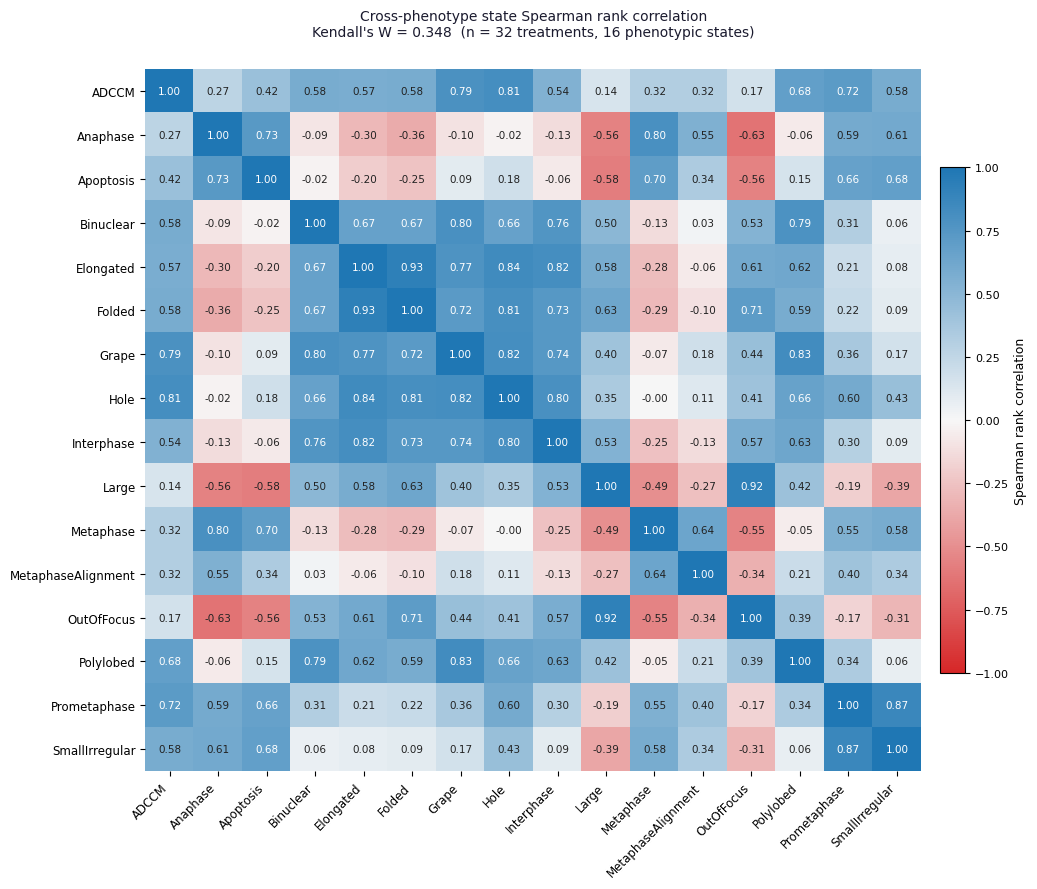

In [ ]:
# p-value via chi-squared approximation:
R = rank_pivot_reranked.values  # (n_subjects, k_raters)
rank_sums = R.sum(axis=1)  # sum across profiles per treatment
S = np.sum((rank_sums - rank_sums.mean()) ** 2)
W = (12 * S) / (k_raters**2 * (n_subjects**3 - n_subjects))

chi2_stat = k_raters * (n_subjects - 1) * W
chi2_pval = chi2_dist.sf(chi2_stat, df=n_subjects - 1)

print(
    f"Kendall's W = {W:.4f}  (0 = fully independent / profile-specific, 1 = perfect agreement)"
)
print(f"χ²({n_subjects - 1}) = {chi2_stat:.4f},  p = {chi2_pval:.4e}")

# ── Cross-profile Spearman correlation matrix ──────────────────────────────────
corr_result = spearmanr(R)
if k_raters == 2:
    rho = float(corr_result.statistic)
    corr_matrix = np.array([[1.0, rho], [rho, 1.0]])
else:
    corr_matrix = np.array(corr_result.statistic)

corr_df = pd.DataFrame(corr_matrix, index=profile_names, columns=profile_names)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9), facecolor="white")

# Diverging colormap: red (negative) → white (0) → blue (positive)
cmap_div = LinearSegmentedColormap.from_list(
    "bwr_mid", ["#d62728", "#f7f7f7", "#1f77b4"], N=256
)

im = ax.imshow(corr_matrix, cmap=cmap_div, vmin=-1, vmax=1, aspect="auto")

# Annotate each cell
for i in range(k_raters):
    for j in range(k_raters):
        val = corr_matrix[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if abs(val) > 0.65 else "#222222",
        )

ax.set_xticks(range(k_raters))
ax.set_yticks(range(k_raters))
ax.set_xticklabels(profile_names, rotation=45, ha="right", fontsize=8.5)
ax.set_yticklabels(profile_names, fontsize=8.5)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("Spearman rank correlation", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title(
    f"Cross-phenotype state Spearman rank correlation\n"
    f"Kendall's W = {W:.3f}  "
    f"(n = {n_subjects} treatments, {k_raters} phenotypic states)\n",
    fontsize=10,
    color="#1a1a2e",
    pad=12,
)

plt.tight_layout()
out_path = output_dir / "profile_rank_consistency.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved → {out_path}")
plt.show()
plt.close()

Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/profile_rank_consistency_clustermap.png


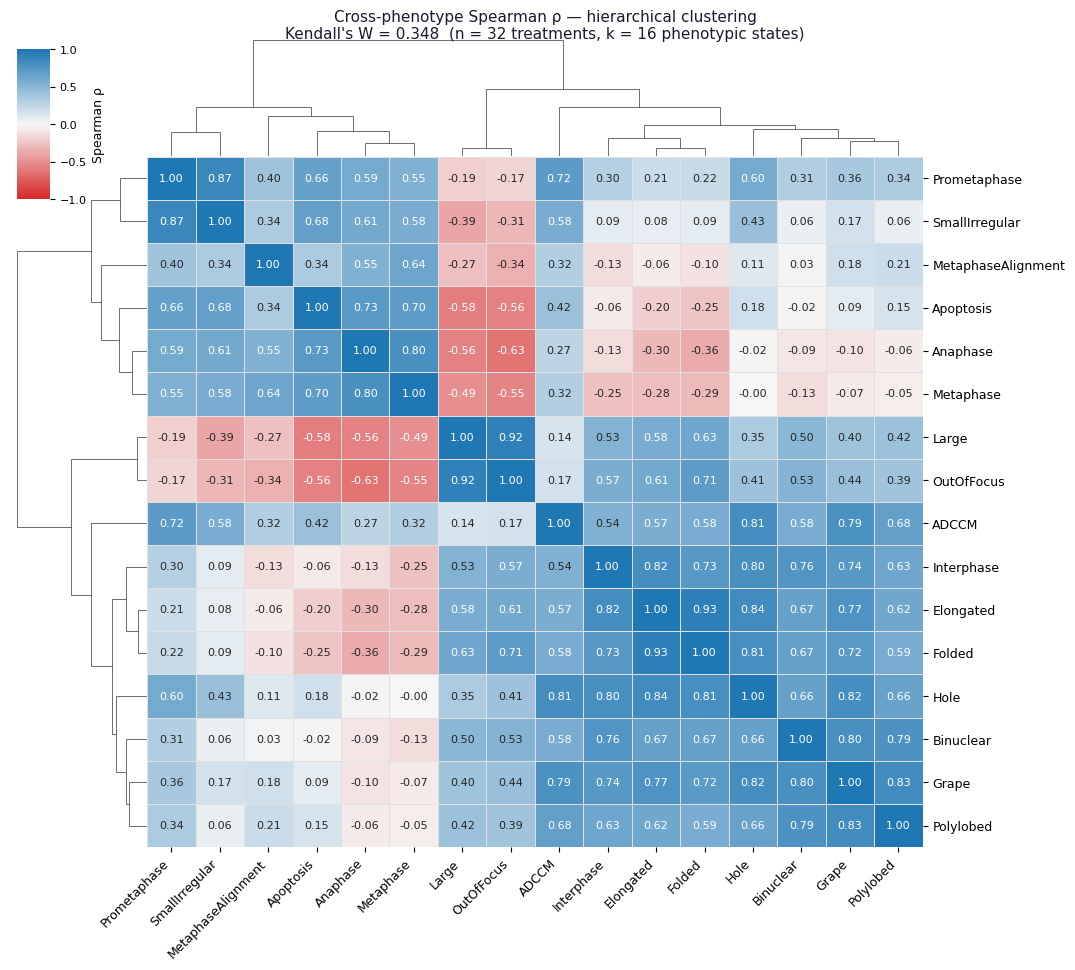

In [ ]:
# ── Seaborn clustermap of cross-profile Spearman correlation ──────────────────
g = sns.clustermap(
    corr_df,
    cmap=cmap_div,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.4,
    linecolor="#e0e0e0",
    figsize=(11, 10),
    dendrogram_ratio=(0.15, 0.15),
    cbar_pos=(0.02, 0.82, 0.03, 0.15),
    xticklabels=True,
    yticklabels=True,
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=9
)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
g.ax_cbar.set_ylabel("Spearman ρ", fontsize=9)
g.ax_cbar.tick_params(labelsize=8)

g.figure.suptitle(
    f"Cross-phenotype Spearman ρ — hierarchical clustering\n"
    f"Kendall's W = {W:.3f}  (n = {n_subjects} treatments, k = {k_raters} phenotypic states)",
    fontsize=11,
    color="#1a1a2e",
    y=1.01,
)

out_path = output_dir / "profile_rank_consistency_clustermap.png"
g.figure.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved → {out_path}")
plt.show()
plt.close()

### Conclusion

**Kendall's W = 0.348** — moderate concordance across 16 profiles on 32 shared treatments. Rankings are neither fully independent nor uniformly consistent, pointing to genuine profile-driven signal with some shared structure explained by biology rather than systematic bias.

The Spearman correlation matrix reveals two broad clusters:

- **Mitotic / cell-death profiles** (Anaphase, Apoptosis, Metaphase, Prometaphase, SmallIrregular) show positive mutual correlations (ρ ≈ 0.6–0.87), meaning they tend to promote the same genes. This is expected — genes disrupting mitosis would score similarly across all mitotic phenotypes.
- **Interphase morphology profiles** (Binuclear, Elongated, Folded, Grape, Hole, Interphase, Polylobed, ADCCM) also correlate positively within the cluster, consistent with genes affecting general cell shape affecting multiple morphology phenotypes.
- Crucially, the two clusters are **negatively correlated with each other** (ρ ≈ −0.02 to −0.63), confirming that genes ranking highly for a mitotic phenotype tend to rank poorly for morphology phenotypes and vice versa — the expected signature of profile-specific signal.

**Notable outliers:** `Large` and `OutOfFocus` have mixed or negative correlations with most other profiles, suggesting they capture highly specific or artefactual phenotypes that share few top-ranked genes with the rest.

**Overall:** The moderate W and the structured block pattern in the correlation matrix confirm that BuSCaR's rankings are primarily profile-driven. The within-cluster positive correlations reflect shared biology (not bias), while the between-cluster negative correlations demonstrate that distinct phenotypes genuinely select different genes.

## Analysis 3: Does Proportion Predict Rank?

**Goal:** Test whether `proportion` — the fraction of cells within a perturbation that display the target phenotype — independently predicts gene rank.

- A strong negative Spearman ρ (higher proportion → lower/better rank) would indicate that phenotypic penetrance is a meaningful driver of prioritisation.
- A flat or near-zero relationship would suggest that rank is determined by the distance scores alone and `proportion` is a corroborating descriptor without independent predictive power.

### Approach
1. **Spearman correlation** — pairwise check of how `proportion` correlates with `rank` per profile and pooled across all profiles.
2. **OLS regression** (`rank ~ proportion`) — estimates the linear relationship and its significance.
3. **Scatter plots** — one panel per phenotypic state showing `proportion` (x) vs `rank` (y) with the Spearman ρ annotated.

In [25]:
# ── Prepare data ───────────────────────────────────────────────────────────────
prop_df = df[["ref_profile", "rank", "proportion"]].dropna().copy()

print(f"Rows used: {len(prop_df)}")
print(f"Profiles:  {prop_df['ref_profile'].nunique()}\n")

# ── 1. Spearman correlation per profile ───────────────────────────────────────
print(f"{'Profile':<20}  {'ρ':>7}  {'p-value':>10}")  #  direction")
print("-" * 55)
for profile, grp in prop_df.groupby("ref_profile"):
    rho, pval = spearmanr(grp["proportion"], grp["rank"])
    direction = "lower rank (better)" if rho < 0 else "higher rank (worse)"
    stars = (
        "***"
        if pval < 0.001
        else "**"
        if pval < 0.01
        else "*"
        if pval < 0.05
        else "n.s."
    )
    print(
        f"{profile:<20}  {rho:+.3f}  {pval:>10.2e}  {stars}"
    )  #  →  higher proportion = {direction}")

# ── 2. Pooled Spearman ────────────────────────────────────────────────────────
rho_all, pval_all = spearmanr(prop_df["proportion"], prop_df["rank"])
print(f"\nPooled (all profiles):  ρ = {rho_all:+.3f}  p = {pval_all:.2e}")

Rows used: 917
Profiles:  16

Profile                     ρ     p-value
-------------------------------------------------------
ADCCM                 -0.319    1.56e-02  *
Anaphase              -0.687    1.81e-09  ***
Apoptosis             -0.834    1.55e-15  ***
Binuclear             -0.793    3.15e-13  ***
Elongated             -0.680    8.44e-09  ***
Folded                -0.590    8.57e-07  ***
Grape                 -0.386    3.00e-03  **
Hole                  -0.623    1.82e-07  ***
Interphase            -0.801    4.45e-14  ***
Large                 -0.717    5.10e-10  ***
Metaphase             -0.716    1.17e-09  ***
MetaphaseAlignment    -0.760    1.05e-11  ***
OutOfFocus            -0.311    1.56e-02  *
Polylobed             -0.731    7.27e-11  ***
Prometaphase          -0.687    1.92e-09  ***
SmallIrregular        -0.689    2.18e-09  ***

Pooled (all profiles):  ρ = -0.634  p = 2.52e-104


In [17]:
# ── 2. OLS regression: rank ~ proportion ─────────────────────────────────────
model_prop = smf.ols("rank ~ proportion", data=prop_df).fit()
print(model_prop.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     181.9
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           6.13e-38
Time:                        13:20:56   Log-Likelihood:                -3793.0
No. Observations:                 917   AIC:                             7590.
Df Residuals:                     915   BIC:                             7600.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     31.6274      0.533     59.394      0.0

Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/proportion_vs_rank_all_profiles.png


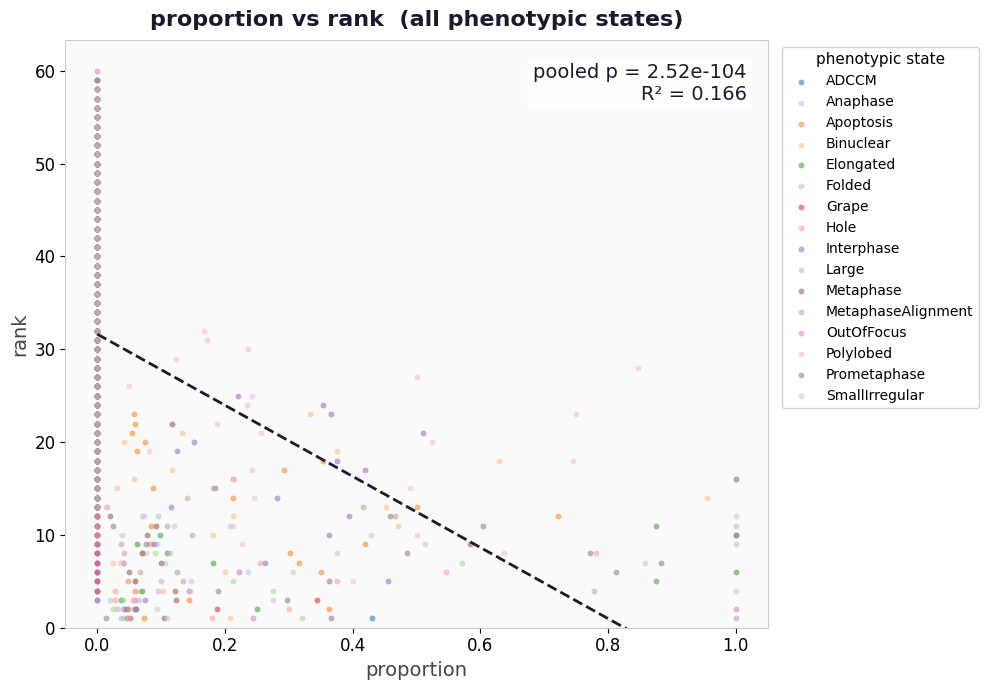

In [ ]:
# ── 3. Scatter: proportion vs rank (all profiles combined) ────────────────────

profiles_sorted_prop = sorted(prop_df["ref_profile"].unique())
palette = sns.color_palette("tab20", n_colors=len(profiles_sorted_prop))
profile_colors = dict(zip(profiles_sorted_prop, palette))

fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")

for profile in profiles_sorted_prop:
    sub = prop_df[prop_df["ref_profile"] == profile]
    ax.scatter(
        sub["proportion"],
        sub["rank"],
        color=profile_colors[profile],
        alpha=0.55,
        s=18,
        linewidths=0,
        label=profile,
        rasterized=True,
    )

# ── OLS regression line ───────────────────────────────────────────────────────
x = prop_df["proportion"].values
y = prop_df["rank"].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(
    x_line,
    m * x_line + b,
    color="#1a1a2e",
    linewidth=2,
    linestyle="--",
    zorder=5,
    label="_nolegend_",
)

# ── Stats annotations ─────────────────────────────────────────────────────────
rho_all, pval_all = spearmanr(x, y)
r_val, _ = pearsonr(x, y)
r2 = r_val**2
stars_all = (
    "***"
    if pval_all < 0.001
    else "**"
    if pval_all < 0.01
    else "*"
    if pval_all < 0.05
    else "n.s."
)

ax.annotate(
    f"pooled p = {pval_all:.2e}\nR² = {r2:.3f}",
    xy=(0.97, 0.96),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=14,
    color="#1a1a2e",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="none"),
)

ax.set_xlabel("proportion", fontsize=14, color="#444")
ax.set_ylabel("rank", fontsize=14, color="#444")
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=12)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
ax.set_facecolor("#fafafa")

ax.legend(
    title="phenotypic state",
    title_fontsize=11,
    fontsize=10,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
)

ax.set_title(
    "proportion vs rank  (all phenotypic states)",
    fontsize=16,
    fontweight="bold",
    color="#1a1a2e",
    pad=10,
)

plt.tight_layout()
out_path = output_dir / "proportion_vs_rank_all_profiles.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved → {out_path}")
plt.show()
plt.close()

**Figure description**

The scatter plot shows all phenotypic states combined, with each state coloured individually. `proportion` (x) represents the fraction of cells displaying the target phenotype; `rank` (y) is the gene's position within that profile (lower = better). The dashed regression line and annotated pooled Spearman ρ (p-value in scientific notation) and R² summarise the overall relationship. A negative ρ means genes with higher phenotypic penetrance tend to receive better (lower) ranks; a near-zero ρ means proportion carries little independent information about rank.


> 

## Analysis 4: Score vs Proportion Correlation per Phenotypic State

Two faceted scatter plots, one per score type:
- **Plot 1:** `on_score` (x) vs `proportion` (y) — one panel per phenotypic state.
- **Plot 2:** `off_score` (x) vs `proportion` (y) — one panel per phenotypic state.

Spearman ρ between the score and `proportion` is annotated in every facet.

Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/on_score_vs_proportion_by_profile.png


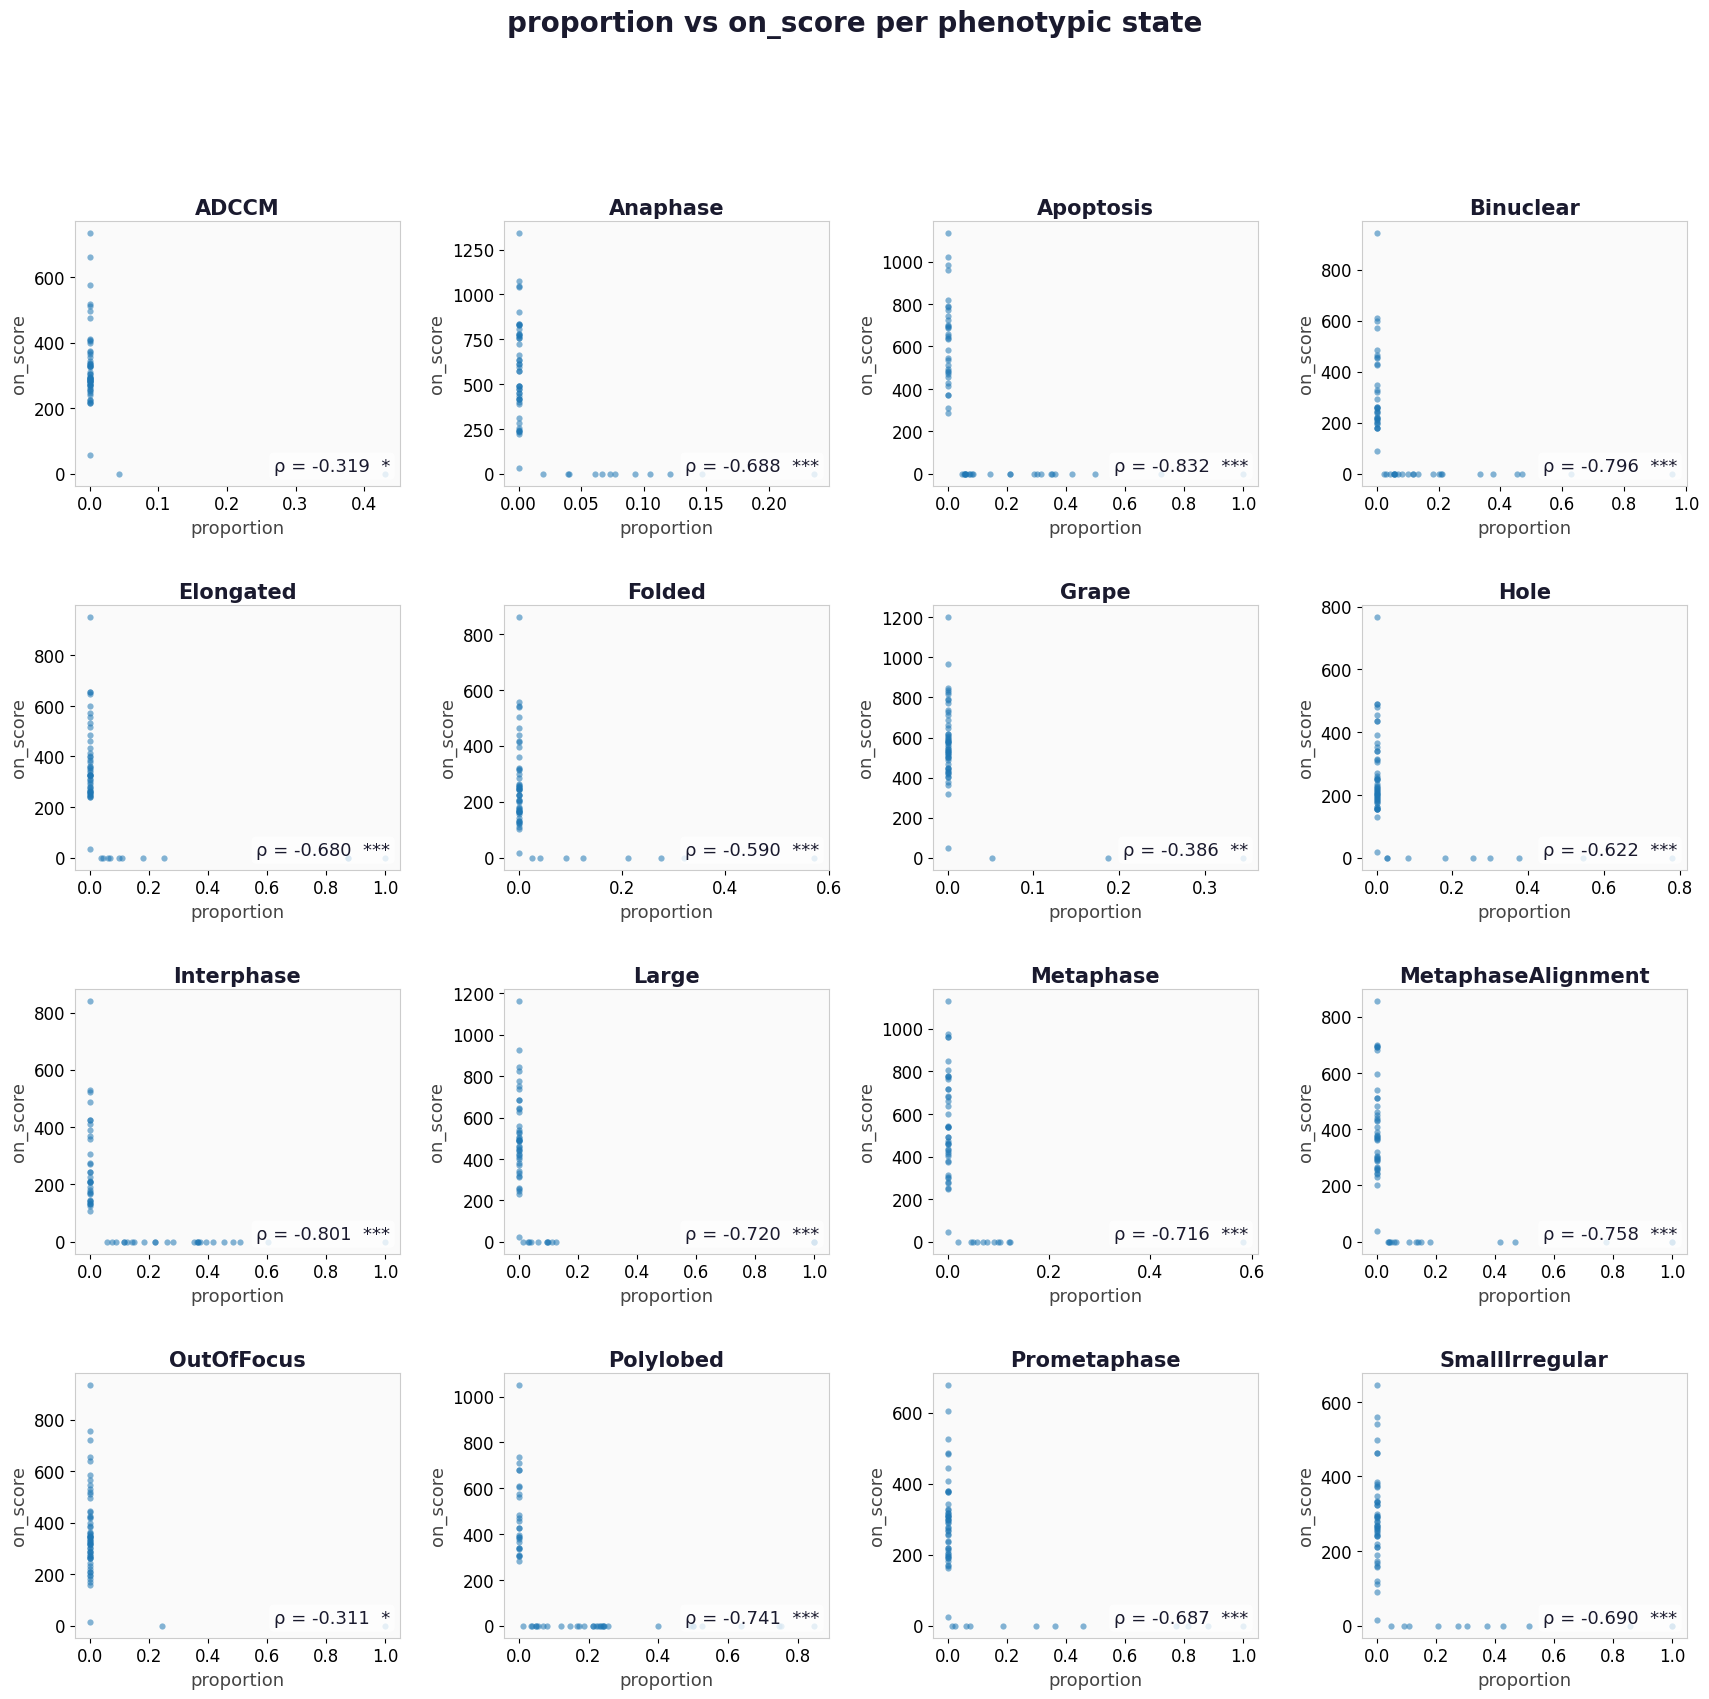

Saved → /home/erikserrano/Projects/buscar/notebooks/_3.Mitocheck-analysis/plots/off_score_vs_proportion_by_profile.png


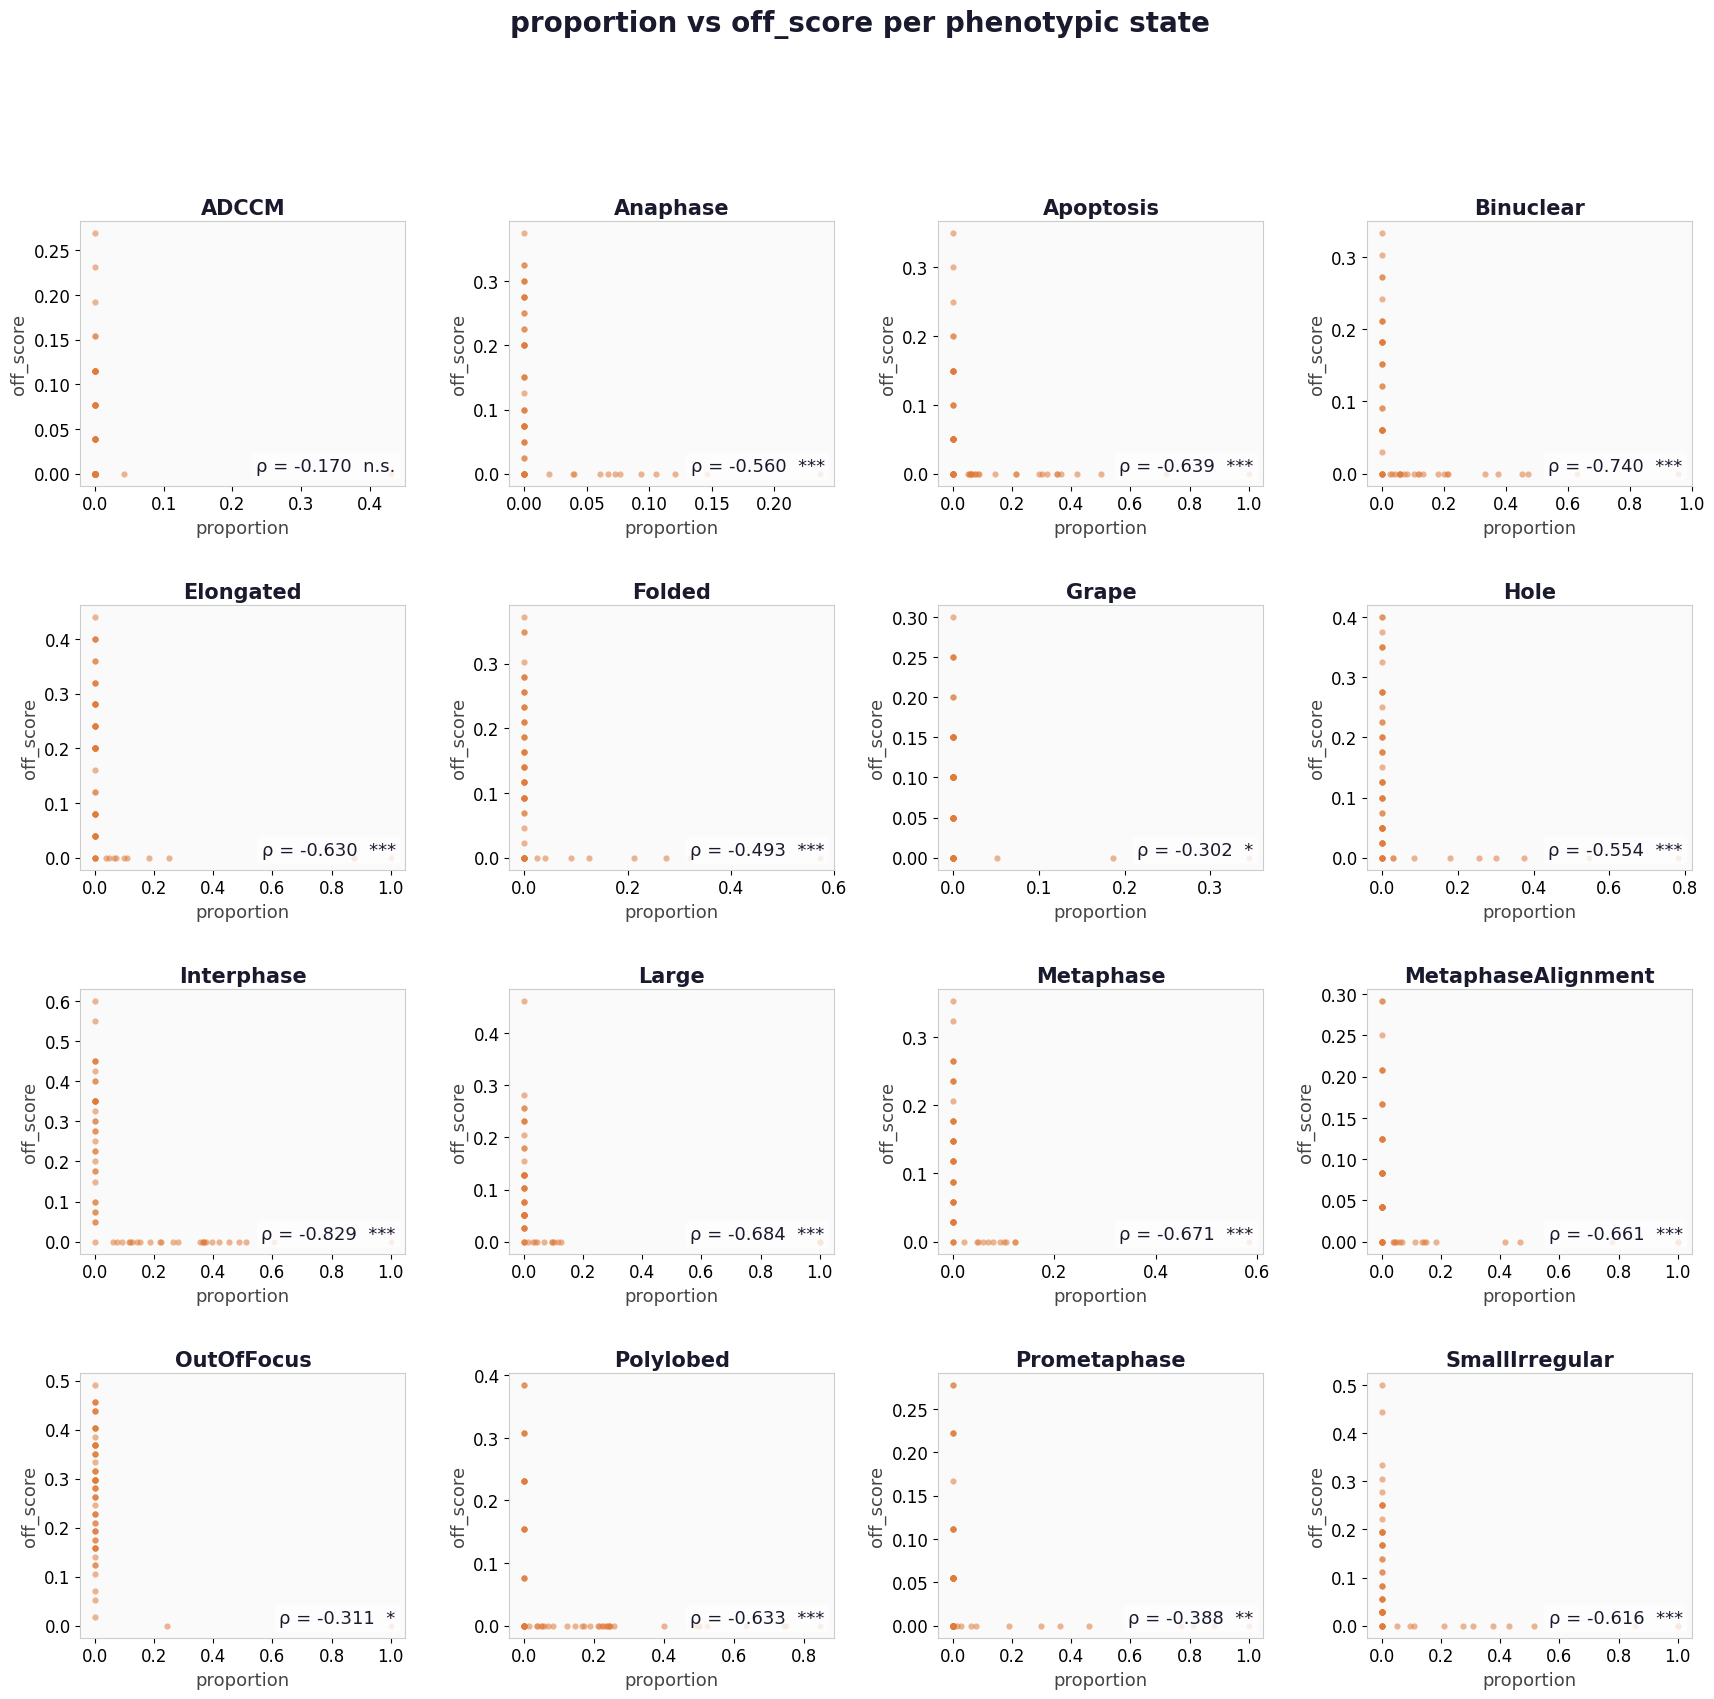

In [13]:
# ── Prepare data ───────────────────────────────────────────────────────────────
plot_df = df[["ref_profile", "on_score", "off_score", "proportion"]].dropna().copy()

profiles_sorted = sorted(plot_df["ref_profile"].unique())
NCOLS = 4
NROWS = int(np.ceil(len(profiles_sorted) / NCOLS))


def facet_score_vs_proportion(score_col, color, title, out_name):
    """Draw a NROWS×NCOLS grid of proportion (x) vs score (y) scatter plots."""
    fig, axes = plt.subplots(
        NROWS,
        NCOLS,
        figsize=(NCOLS * 5.2, NROWS * 4.6),
        facecolor="white",
    )
    axes_flat = axes.flatten()

    for ax_idx, profile in enumerate(profiles_sorted):
        ax = axes_flat[ax_idx]
        sub = plot_df[plot_df["ref_profile"] == profile]

        ax.scatter(
            sub["proportion"],
            sub[score_col],
            color=color,
            alpha=0.55,
            s=20,
            linewidths=0,
            rasterized=True,
        )

        # ── Spearman ρ annotation ─────────────────────────────────────────────
        rho, pval = spearmanr(sub["proportion"], sub[score_col])
        stars = (
            "***"
            if pval < 0.001
            else "**"
            if pval < 0.01
            else "*"
            if pval < 0.05
            else "n.s."
        )
        ax.annotate(
            f"ρ = {rho:+.3f}  {stars}",
            xy=(0.97, 0.04),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=13,
            color="#1a1a2e",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.80, ec="none"),
        )

        ax.set_title(profile, fontsize=15, fontweight="bold", color="#1a1a2e", pad=5)
        ax.set_xlabel("proportion", fontsize=13, color="#444")
        ax.set_ylabel(score_col, fontsize=13, color="#444")
        ax.tick_params(labelsize=12)
        for spine in ax.spines.values():
            spine.set_color("#cccccc")
        ax.set_facecolor("#fafafa")

    # ── Hide empty axes ────────────────────────────────────────────────────────
    for ax in axes_flat[len(profiles_sorted) :]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=20, fontweight="bold", color="#1a1a2e", y=0.995)
    fig.subplots_adjust(hspace=0.45, wspace=0.32)

    out_path = output_dir / out_name
    plt.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
    print(f"Saved → {out_path}")
    plt.show()
    plt.close()


# ── Plot 1: proportion vs on_score ────────────────────────────────────────────
facet_score_vs_proportion(
    score_col="on_score",
    color="#1f77b4",
    title="proportion vs on_score per phenotypic state",
    out_name="on_score_vs_proportion_by_profile.png",
)

# ── Plot 2: proportion vs off_score ───────────────────────────────────────────
facet_score_vs_proportion(
    score_col="off_score",
    color="#e07b39",
    title="proportion vs off_score per phenotypic state",
    out_name="off_score_vs_proportion_by_profile.png",
)